# Home Battery Savings Analysis

**Question:** How much would I save over a year if a home battery charged overnight (cheap) and covered daytime usage, and how well would a real 20.7 kWh battery actually cope?

**Tariff — Octopus Intelligent Go**

| Rate | Price | Hours (local time) |
| :--- | :--- | :--- |
| Peak | 30.27p/kWh | 05:00–23:00 |
| Off-peak | 6.9p/kWh | 23:00–05:00 |

**Sections**

1. Load and clean one year of half-hourly consumption (1 Jul 2025 – 1 Jul 2026).
2. Label peak / off-peak and cost each half-hour.
3. Idealised upper bound — every kWh re-priced at off-peak (perfect, lossless battery).
4. Monthly breakdown.
5. Average daily consumption profile.
6. Realistic capacity-constrained simulation (20.7 kWh, 6 kW, 90% round-trip).
7. Battery-exceedance view — the days and times the battery can't keep up (anomaly spotting).
8. Estimating and removing EV charging to isolate home-only load.

> **Idealised vs realistic.** Section 3 re-prices all usage at off-peak — the *maximum* achievable saving (a battery large enough to cover every day with zero losses). Section 6 onwards constrains capacity, power and efficiency for a realistic figure.

In [23]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

# Octopus Intelligent Go tariff (£/kWh)
PEAK_RATE = 0.3027       # 05:00–23:00
OFFPEAK_RATE = 0.069     # 23:00–05:00

DATA_DIR = Path("../files") if Path("../files").exists() else Path("files")
CSV_PATH = DATA_DIR / "010725 - 010726 electricity consumption.csv"
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

print("Data file:", CSV_PATH)
print("Exists:", CSV_PATH.exists())

Data file: ..\files\010725 - 010726 electricity consumption.csv
Exists: True


## 1. Load and clean the data

Parse timestamps to UTC and convert to `Europe/London` so peak/off-peak is judged on the **local wall-clock hour** (correctly handles the BST/GMT switch).

In [24]:
raw = pd.read_csv(CSV_PATH, skipinitialspace=True)
raw.columns = [c.strip() for c in raw.columns]

df = raw.rename(columns={"Consumption (kwh)": "kwh", "Start": "start", "End": "end"})
df["kwh"] = pd.to_numeric(df["kwh"], errors="coerce")
# ISO8601 handles the mixed fractional seconds in the final row; convert to UK local time
df["start"] = pd.to_datetime(df["start"], format="ISO8601", utc=True).dt.tz_convert("Europe/London")
df["end"] = pd.to_datetime(df["end"], format="ISO8601", utc=True).dt.tz_convert("Europe/London")
df = df.dropna(subset=["kwh"]).sort_values("start").reset_index(drop=True)

# Validation
n = len(df)
dups = int(df["start"].duplicated().sum())
gap = df["start"].diff().dropna()
irregular = int((gap != pd.Timedelta(minutes=30)).sum())
print(f"Rows:                 {n:,}")
print(f"Duplicate starts:     {dups}")
print(f"Non-30-min gaps:      {irregular}  (DST changes expected)")
print(f"Span:                 {df['start'].min()}  ->  {df['start'].max()}")
print(f"Days of data:         {n / 48:.1f}")
print(f"Total consumption:    {df['kwh'].sum():,.1f} kWh")
df.head()

Rows:                 17,568
Duplicate starts:     0
Non-30-min gaps:      0  (DST changes expected)
Span:                 2025-07-01 00:00:00+01:00  ->  2026-07-01 23:30:00+01:00
Days of data:         366.0
Total consumption:    7,573.8 kWh


,kwh,start,end
0,0.137,2025-07-01 00:00:00+01:00,2025-07-01 00:30:00+01:00
1,0.133,2025-07-01 00:30:00+01:00,2025-07-01 01:00:00+01:00
2,0.111,2025-07-01 01:00:00+01:00,2025-07-01 01:30:00+01:00
3,0.109,2025-07-01 01:30:00+01:00,2025-07-01 02:00:00+01:00
4,0.109,2025-07-01 02:00:00+01:00,2025-07-01 02:30:00+01:00


## 2. Label periods and cost each half-hour

Off-peak = start hour in 23:00–05:00 (hours 23, 0, 1, 2, 3, 4); everything else is peak.

In [25]:
hour = df["start"].dt.hour
df["is_offpeak"] = (hour >= 23) | (hour < 5)
df["period"] = df["is_offpeak"].map({True: "off-peak", False: "peak"})
df["rate"] = df["is_offpeak"].map({True: OFFPEAK_RATE, False: PEAK_RATE})

# Split kWh by period for easy aggregation
df["peak_kwh"] = df["kwh"].where(~df["is_offpeak"], 0.0)
df["offpeak_kwh"] = df["kwh"].where(df["is_offpeak"], 0.0)

# Costs
df["actual_cost"] = df["kwh"] * df["rate"]          # current tariff
df["ideal_cost"] = df["kwh"] * OFFPEAK_RATE          # perfect battery: all off-peak

df[["start", "kwh", "period", "rate", "actual_cost", "ideal_cost"]].head()

,start,kwh,period,rate,actual_cost,ideal_cost
0,2025-07-01 00:00:00+01:00,0.137,off-peak,0.069,0.009453,0.009453
1,2025-07-01 00:30:00+01:00,0.133,off-peak,0.069,0.009177,0.009177
2,2025-07-01 01:00:00+01:00,0.111,off-peak,0.069,0.007659,0.007659
3,2025-07-01 01:30:00+01:00,0.109,off-peak,0.069,0.007521,0.007521
4,2025-07-01 02:00:00+01:00,0.109,off-peak,0.069,0.007521,0.007521


## 3. Yearly totals and headline saving

In [26]:
total_kwh = df["kwh"].sum()
peak_kwh = df["peak_kwh"].sum()
offpeak_kwh = df["offpeak_kwh"].sum()
actual_cost = df["actual_cost"].sum()
ideal_cost = df["ideal_cost"].sum()
saving = actual_cost - ideal_cost

print("=== Consumption ===")
print(f"Total:                  {total_kwh:>10,.1f} kWh")
print(f"Peak (05:00-23:00):     {peak_kwh:>10,.1f} kWh  ({peak_kwh / total_kwh:.1%})")
print(f"Off-peak (23:00-05:00): {offpeak_kwh:>10,.1f} kWh  ({offpeak_kwh / total_kwh:.1%})")
print()
print("=== Annual cost ===")
print(f"Actual (current tariff):         £{actual_cost:>9,.2f}")
print(f"Idealised (all @ 6.9p off-peak): £{ideal_cost:>9,.2f}")
print(f"Saving:                          £{saving:>9,.2f}  ({saving / actual_cost:.1%})")
print()
print(f"Blended actual rate: {actual_cost / total_kwh * 100:.2f} p/kWh  ->  off-peak {OFFPEAK_RATE * 100:.2f} p/kWh")

=== Consumption ===
Total:                     7,573.8 kWh
Peak (05:00-23:00):        5,486.9 kWh  (72.4%)
Off-peak (23:00-05:00):    2,086.9 kWh  (27.6%)

=== Annual cost ===
Actual (current tariff):         £ 1,804.88
Idealised (all @ 6.9p off-peak): £   522.59
Saving:                          £ 1,282.28  (71.0%)

Blended actual rate: 23.83 p/kWh  ->  off-peak 6.90 p/kWh


## 4. Monthly breakdown

In [27]:
monthly = (
    df.set_index("start")
    .resample("MS")
    .agg(
        total_kwh=("kwh", "sum"),
        peak_kwh=("peak_kwh", "sum"),
        offpeak_kwh=("offpeak_kwh", "sum"),
        actual_cost=("actual_cost", "sum"),
        ideal_cost=("ideal_cost", "sum"),
    )
)
monthly["saving"] = monthly["actual_cost"] - monthly["ideal_cost"]
monthly["peak_pct"] = monthly["peak_kwh"] / monthly["total_kwh"]

table = monthly.copy()
table.index = table.index.strftime("%b %Y")
table.columns = ["Total kWh", "Peak kWh", "Off-pk kWh", "Actual £", "Ideal £", "Saving £", "Peak %"]
table.round({"Total kWh": 1, "Peak kWh": 1, "Off-pk kWh": 1,
            "Actual £": 2, "Ideal £": 2, "Saving £": 2, "Peak %": 3})

,Total kWh,Peak kWh,Off-pk kWh,Actual £,Ideal £,Saving £,Peak %
start,,,,,,,
Jul 2025,648.8,496.6,152.2,160.83,44.77,116.07,0.765
Aug 2025,507.7,404.3,103.4,129.52,35.03,94.49,0.796
Sep 2025,560.3,430.2,130.1,139.20,38.66,100.54,0.768
Oct 2025,712.5,461.3,251.2,156.97,49.16,107.81,0.647
Nov 2025,673.4,477.1,196.3,157.98,46.47,111.51,0.709
Dec 2025,780.3,558.6,221.6,184.39,53.84,130.55,0.716
Jan 2026,722.6,505.3,217.4,167.94,49.86,118.08,0.699
Feb 2026,612.2,418.9,193.3,140.13,42.24,97.89,0.684
Mar 2026,637.5,426.3,211.3,143.61,43.99,99.62,0.669


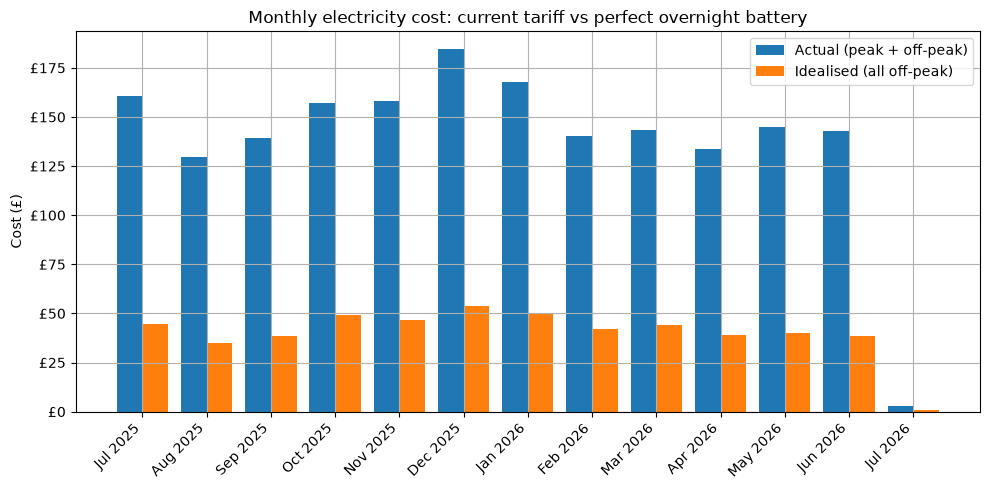

In [28]:
labels = monthly.index.strftime("%b %Y")

fig, ax = plt.subplots()
x = range(len(monthly))
width = 0.4
ax.bar([i - width / 2 for i in x], monthly["actual_cost"], width, label="Actual (peak + off-peak)")
ax.bar([i + width / 2 for i in x], monthly["ideal_cost"], width, label="Idealised (all off-peak)")
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Cost (£)")
ax.set_title("Monthly electricity cost: current tariff vs perfect overnight battery")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("£%.0f"))
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "monthly_cost_comparison.png", dpi=120)
plt.show()

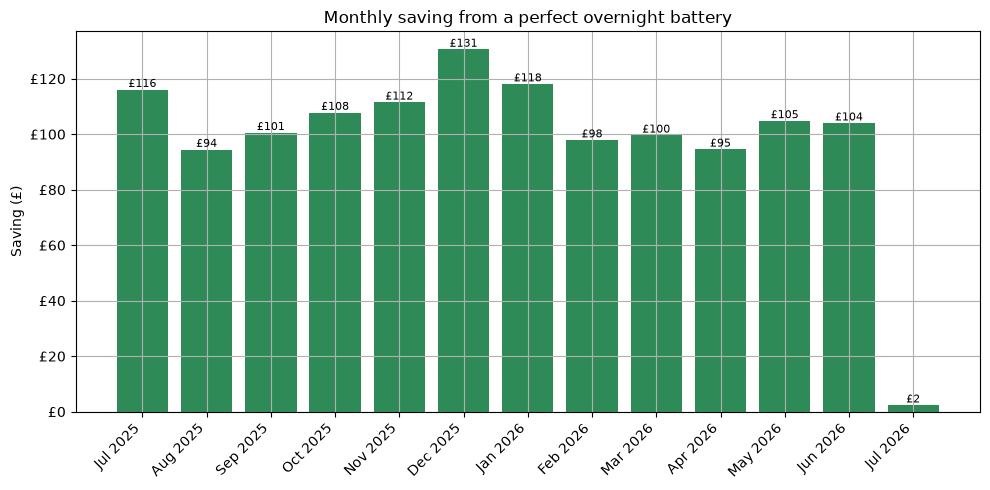

In [29]:
fig, ax = plt.subplots()
ax.bar(labels, monthly["saving"], color="seagreen")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_ylabel("Saving (£)")
ax.set_title("Monthly saving from a perfect overnight battery")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("£%.0f"))
for i, v in enumerate(monthly["saving"]):
    ax.text(i, v, f"£{v:.0f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "monthly_savings.png", dpi=120)
plt.show()

## 5. When is the energy used? Average daily profile

Where consumption sits across the day drives the saving: load in the shaded off-peak window is already cheap, so the opportunity is the daytime peak.

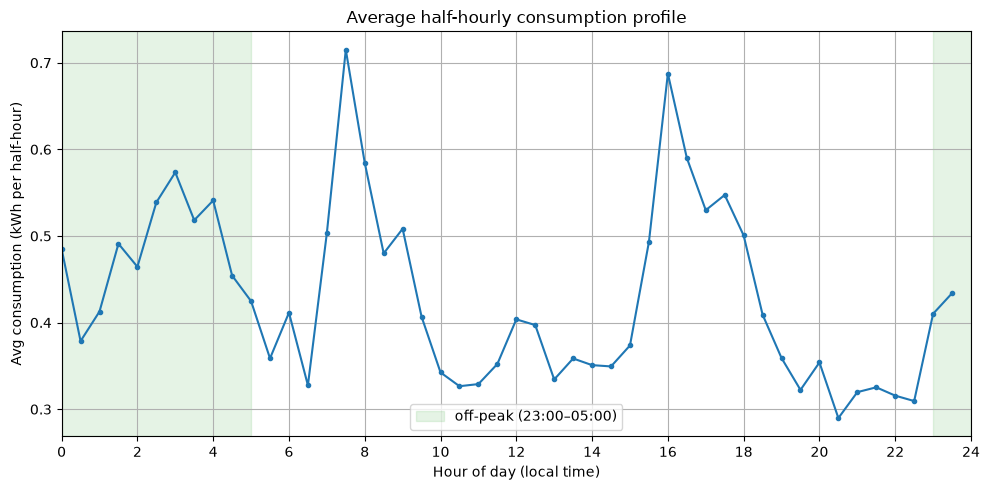

In [30]:
prof = df.assign(hour_dec=df["start"].dt.hour + df["start"].dt.minute / 60)
avg = prof.groupby("hour_dec")["kwh"].mean()

fig, ax = plt.subplots()
ax.plot(avg.index, avg.values, marker=".")
ax.axvspan(0, 5, color="tab:green", alpha=0.12, label="off-peak (23:00–05:00)")
ax.axvspan(23, 24, color="tab:green", alpha=0.12)
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 2))
ax.set_xlabel("Hour of day (local time)")
ax.set_ylabel("Avg consumption (kWh per half-hour)")
ax.set_title("Average half-hourly consumption profile")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "daily_profile.png", dpi=120)
plt.show()

## 6. Realistic capacity-constrained battery simulation

Section 3 gave the *idealised* upper bound (every kWh re-priced at off-peak). Here we simulate an actual battery, half-hour by half-hour, so the saving reflects real limits.

**Battery (Fox ESS EP12 double stack, as quoted)**

| Parameter | Value |
| :--- | :--- |
| Usable capacity | 20.7 kWh |
| Inverter power | 6.0 kW → 3.0 kWh per half-hour |
| Round-trip efficiency | 90% (split √0.9 each way) |

**Strategy (import-only self-use on Intelligent Go)**

1. **Off-peak (23:00–05:00):** home load is served from the grid at 6.9p; spare inverter capacity charges the battery from the grid up to full.
2. **Peak (05:00–23:00):** home load is served from the battery until it hits the power limit or empties; any shortfall is imported at 30.27p.

**Assumptions:** no solar and no export (import savings only); standing charge ignored (identical in both scenarios); no degradation; perfect foresight not required because the strategy is simple (fill nightly, drain by day).

In [31]:
import numpy as np


def simulate_battery(frame, usable_kwh=20.7, max_kw=6.0, round_trip=0.90, reserve_kwh=0.0):
    """Half-hourly import-only battery sim: charge off-peak, discharge peak.

    Returns (summary dict, per-slot results DataFrame).
    """
    eff = round_trip**0.5            # applied on both charge and discharge
    max_e = max_kw * 0.5            # per half-hour energy limit (kWh)

    load = frame["kwh"].to_numpy(dtype=float)
    is_off = frame["is_offpeak"].to_numpy(dtype=bool)
    n = len(frame)

    soc = np.empty(n)               # state of charge after each slot (kWh)
    grid_import = np.empty(n)       # grid energy drawn this slot (kWh)
    grid_cost = np.empty(n)         # £ this slot
    batt_to_home = np.empty(n)      # kWh delivered from battery to home

    charge = 0.0
    for i in range(n):
        if is_off[i]:
            room = usable_kwh - charge
            charge_ac = min(max_e, room / eff) if room > 0 else 0.0
            charge += charge_ac * eff
            imp = load[i] + charge_ac
            grid_import[i] = imp
            grid_cost[i] = imp * OFFPEAK_RATE
            batt_to_home[i] = 0.0
        else:
            avail = max((charge - reserve_kwh) * eff, 0.0)
            deliver = min(load[i], max_e, avail)
            charge -= deliver / eff
            residual = load[i] - deliver
            grid_import[i] = residual
            grid_cost[i] = residual * PEAK_RATE
            batt_to_home[i] = deliver
        soc[i] = charge

    res = frame[["start", "kwh", "is_offpeak"]].copy()
    res["soc"] = soc
    res["grid_import"] = grid_import
    res["grid_cost"] = grid_cost
    res["batt_to_home"] = batt_to_home

    base_rate = np.where(is_off, OFFPEAK_RATE, PEAK_RATE)
    baseline_cost = float((load * base_rate).sum())
    battery_cost = float(grid_cost.sum())
    peak_load = float(load[~is_off].sum())
    delivered = float(batt_to_home.sum())
    charge_import = float(grid_import[is_off].sum() - load[is_off].sum())

    daily_residual_peak = (
        res.loc[~res["is_offpeak"]].set_index("start")["grid_import"].resample("D").sum()
    )
    days_total = int(daily_residual_peak.size)
    days_fully_covered = int((daily_residual_peak < 1e-6).sum())

    summary = {
        "usable_kwh": usable_kwh,
        "baseline_cost": baseline_cost,
        "battery_cost": battery_cost,
        "saving": baseline_cost - battery_cost,
        "peak_load": peak_load,
        "peak_covered": delivered,
        "peak_covered_pct": delivered / peak_load,
        "charge_import": charge_import,
        "round_trip_loss": charge_import - delivered,
        "equiv_full_cycles": delivered / eff / usable_kwh,
        "days_total": days_total,
        "days_fully_covered": days_fully_covered,
    }
    return summary, res


In [32]:
USABLE_KWH = 20.7
sim, sim_res = simulate_battery(df, usable_kwh=USABLE_KWH)

ideal_saving = actual_cost - ideal_cost  # from Section 3

print(f"Battery: {USABLE_KWH} kWh usable, 6.0 kW, 90% round-trip\n")
print("=== Annual cost ===")
print(f"Baseline (no battery):        £{sim['baseline_cost']:>9,.2f}")
print(f"With battery (realistic):     £{sim['battery_cost']:>9,.2f}")
print(f"Idealised (all off-peak):     £{ideal_cost:>9,.2f}")
print()
print("=== Annual saving ===")
print(f"Realistic:                    £{sim['saving']:>9,.2f}  ({sim['saving'] / sim['baseline_cost']:.1%})")
print(f"Idealised (upper bound):      £{ideal_saving:>9,.2f}  ({ideal_saving / sim['baseline_cost']:.1%})")
print(f"Realistic captures {sim['saving'] / ideal_saving:.0%} of the idealised maximum.")
print()
print("=== Battery behaviour ===")
print(f"Peak load covered by battery: {sim['peak_covered']:,.0f} / {sim['peak_load']:,.0f} kWh  ({sim['peak_covered_pct']:.1%})")
print(f"Grid energy used to charge:   {sim['charge_import']:,.0f} kWh")
print(f"Round-trip losses:            {sim['round_trip_loss']:,.0f} kWh")
print(f"Equivalent full cycles/yr:    {sim['equiv_full_cycles']:,.0f}")
print(f"Days battery fully covered daytime: {sim['days_fully_covered']} / {sim['days_total']}")


Battery: 20.7 kWh usable, 6.0 kW, 90% round-trip

=== Annual cost ===
Baseline (no battery):        £ 1,804.88
With battery (realistic):     £   699.29
Idealised (all off-peak):     £   522.59

=== Annual saving ===
Realistic:                    £ 1,105.59  (61.3%)
Idealised (upper bound):      £ 1,282.28  (71.0%)
Realistic captures 86% of the idealised maximum.

=== Battery behaviour ===
Peak load covered by battery: 4,896 / 5,487 kWh  (89.2%)
Grid energy used to charge:   5,457 kWh
Round-trip losses:            561 kWh
Equivalent full cycles/yr:    249
Days battery fully covered daytime: 280 / 366


### Monthly: realistic vs idealised saving

The gap between the two lines is the saving lost to capacity and efficiency limits — largest in high-consumption winter months when daytime load exceeds what the battery can hold.

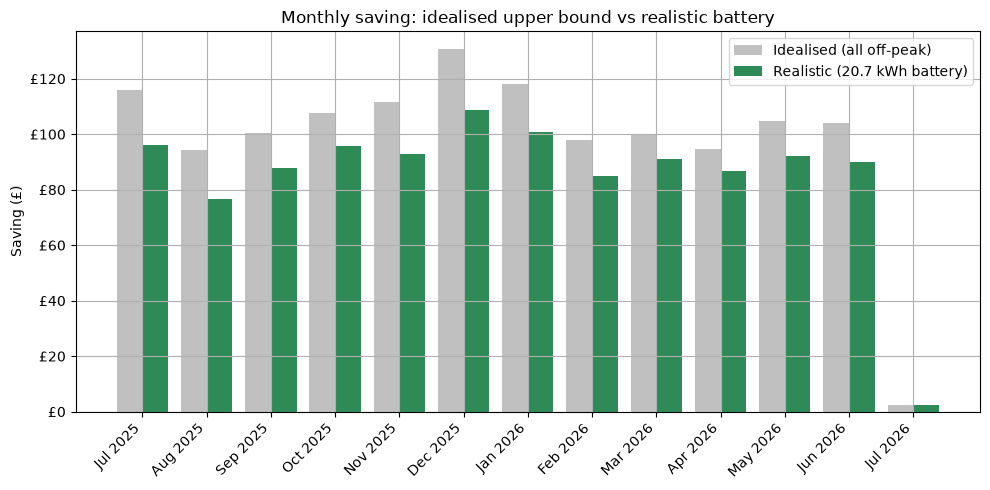

In [33]:
realistic_cost_m = sim_res.set_index("start")["grid_cost"].resample("MS").sum()
comp = pd.DataFrame({
    "realistic_saving": monthly["actual_cost"] - realistic_cost_m,
    "ideal_saving": monthly["saving"],
})
clabels = comp.index.strftime("%b %Y")

fig, ax = plt.subplots()
xi = range(len(comp))
width = 0.4
ax.bar([i - width / 2 for i in xi], comp["ideal_saving"], width, label="Idealised (all off-peak)", color="silver")
ax.bar([i + width / 2 for i in xi], comp["realistic_saving"], width, label="Realistic (20.7 kWh battery)", color="seagreen")
ax.set_xticks(list(xi))
ax.set_xticklabels(clabels, rotation=45, ha="right")
ax.set_ylabel("Saving (£)")
ax.set_title("Monthly saving: idealised upper bound vs realistic battery")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("£%.0f"))
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "monthly_saving_realistic_vs_ideal.png", dpi=120)
plt.show()

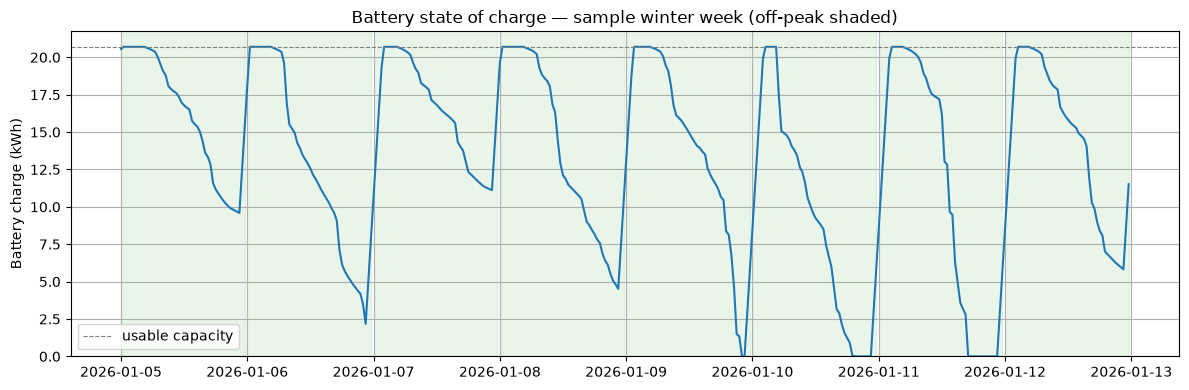

In [34]:
# Battery state of charge over a sample winter week
window = sim_res.set_index("start").loc["2026-01-05":"2026-01-12"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(window.index, window["soc"], color="tab:blue")
ax.axhline(USABLE_KWH, color="grey", ls="--", lw=0.8, label="usable capacity")
for day, grp in window.groupby(window.index.normalize()):
    off = grp[grp["is_offpeak"]]
    if not off.empty:
        ax.axvspan(off.index.min(), off.index.max(), color="tab:green", alpha=0.10)
ax.set_ylabel("Battery charge (kWh)")
ax.set_title("Battery state of charge — sample winter week (off-peak shaded)")
ax.set_ylim(0, USABLE_KWH * 1.05)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "soc_sample_week.png", dpi=120)
plt.show()

## 7. Where the battery is exceeded — spotting anomalies (e.g. daytime EV charging)

In the realistic simulation, **any grid import during peak hours is demand the battery could not meet.** That happens for two reasons:

- **Capacity** — the battery emptied before the next off-peak window (typical on high-consumption winter days).
- **Power** — a single half-hour drew more than the 6 kW inverter can deliver (> 3.0 kWh in 30 min). A ~7 kW EV charger (~3.8 kWh/half-hour) trips this every slot it runs.

Daytime EV charging shows up as **blocks of high, power-limited half-hours** — distinct from the diffuse winter-evening shortfall. The views below highlight the exact **days and times** so anomalous days can be flagged for follow-up once the EV charging log is available for this period.

In [35]:
MAX_HH_KWH = 6.0 * 0.5  # inverter power limit per half-hour (6 kW)

exc = sim_res.copy()
peak = ~exc["is_offpeak"]
exc["date"] = exc["start"].dt.normalize()
exc["tod"] = exc["start"].dt.hour + exc["start"].dt.minute / 60
exc["shortfall"] = np.where(peak, exc["grid_import"], 0.0)      # unmet peak demand (kWh)
exc["daytime_kwh"] = np.where(peak, exc["kwh"], np.nan)         # load during peak only
exc["power_limited"] = (peak & (exc["kwh"] > MAX_HH_KWH)).astype(int)

daily = exc.groupby("date").agg(
    shortfall_kwh=("shortfall", "sum"),
    max_daytime_hh_kwh=("daytime_kwh", "max"),
    power_limited_slots=("power_limited", "sum"),
    peak_load_kwh=("daytime_kwh", "sum"),
)
daily["exceeded"] = daily["shortfall_kwh"] > 1e-6

n_exceeded = int(daily["exceeded"].sum())
n_power = int((daily["power_limited_slots"] > 0).sum())
print(f"Days with any peak shortfall:        {n_exceeded} / {len(daily)}")
print(f"Days with a >6 kW half-hour (power): {n_power}  <- strongest EV / large-load candidates")
print(f"Total unmet peak demand:             {daily['shortfall_kwh'].sum():,.0f} kWh")
print(f"...imported at peak, costing:        £{daily['shortfall_kwh'].sum() * PEAK_RATE:,.2f}\n")

worst = daily.sort_values("shortfall_kwh", ascending=False).head(15).copy()
worst_view = worst[["shortfall_kwh", "max_daytime_hh_kwh", "power_limited_slots", "peak_load_kwh"]]
worst_view.index = worst_view.index.strftime("%a %d %b %Y")
worst_view.round(2)

Days with any peak shortfall:        86 / 366
Days with a >6 kW half-hour (power): 83  <- strongest EV / large-load candidates
Total unmet peak demand:             591 kWh
...imported at peak, costing:        £178.76



,shortfall_kwh,max_daytime_hh_kwh,power_limited_slots,peak_load_kwh
date,,,,
Mon 01 Jun 2026,25.57,4.00,9,45.21
Sun 24 May 2026,23.76,4.29,8,43.40
Thu 14 Aug 2025,23.45,4.14,8,43.09
Sun 11 Jan 2026,20.96,4.07,8,40.60
Fri 16 Jan 2026,17.38,4.13,6,37.01
Sat 22 Nov 2025,17.19,4.08,6,36.83
Wed 26 Nov 2025,16.71,4.11,5,36.35
Tue 09 Dec 2025,16.66,3.85,4,36.30
Thu 02 Oct 2025,16.54,4.66,6,36.17


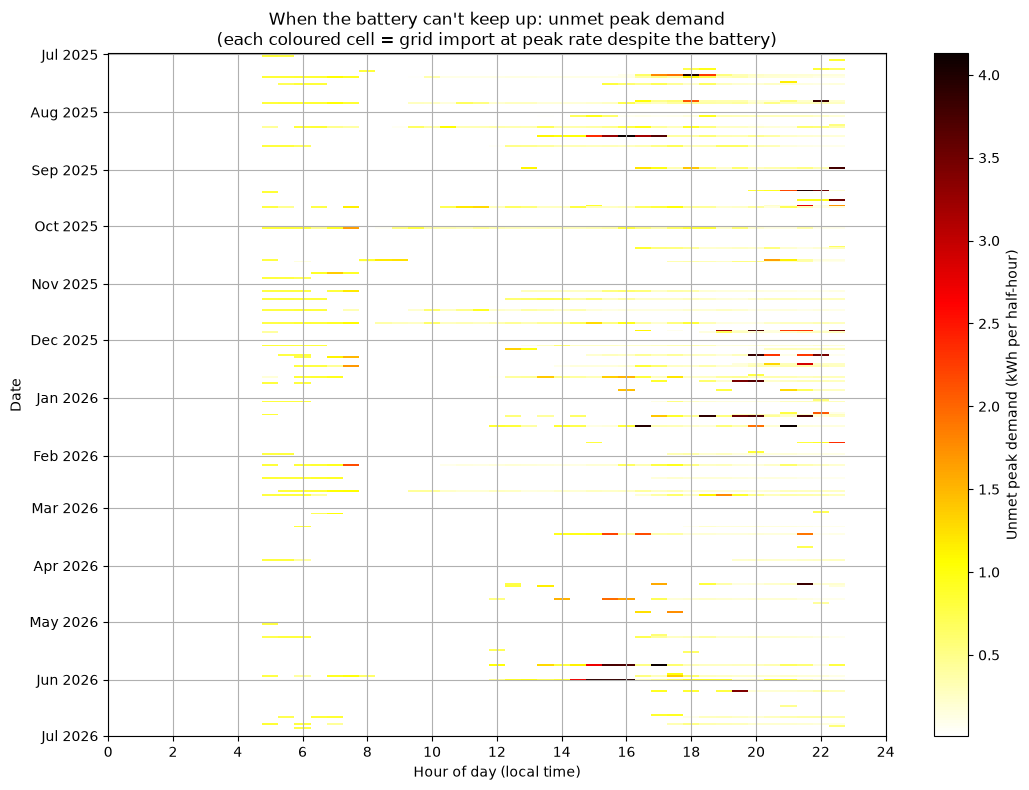

In [36]:
import matplotlib.dates as mdates

pivot = exc.pivot_table(index="date", columns="tod", values="shortfall", aggfunc="sum")
grid = np.ma.masked_less_equal(pivot.to_numpy(), 0.0)          # hide covered/off-peak slots
y = mdates.date2num(pivot.index.tz_localize(None).to_pydatetime())
x = pivot.columns.to_numpy()

fig, ax = plt.subplots(figsize=(11, 8))
mesh = ax.pcolormesh(x, y, grid, cmap="hot_r", shading="nearest")
ax.yaxis_date()
ax.yaxis.set_major_locator(mdates.MonthLocator())
ax.yaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.invert_yaxis()
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 2))
ax.set_xlabel("Hour of day (local time)")
ax.set_ylabel("Date")
ax.set_title("When the battery can't keep up: unmet peak demand\n(each coloured cell = grid import at peak rate despite the battery)")
cb = fig.colorbar(mesh, ax=ax)
cb.set_label("Unmet peak demand (kWh per half-hour)")
plt.tight_layout()
plt.savefig(OUT_DIR / "battery_exceedance_heatmap.png", dpi=120)
plt.show()

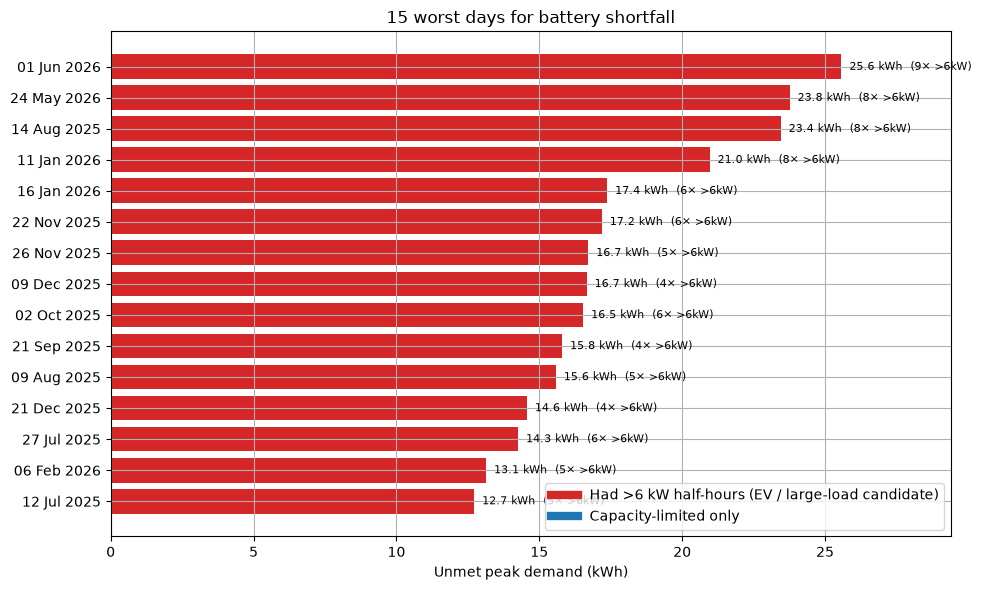

In [37]:
top = daily.sort_values("shortfall_kwh", ascending=False).head(15).iloc[::-1]
tlabels = top.index.strftime("%d %b %Y")
colors = ["tab:red" if s > 0 else "tab:blue" for s in top["power_limited_slots"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(tlabels, top["shortfall_kwh"], color=colors)
for i, (val, pw) in enumerate(zip(top["shortfall_kwh"], top["power_limited_slots"])):
    tag = f"{val:.1f} kWh" + (f"  ({pw}× >6kW)" if pw > 0 else "")
    ax.text(val, i, "  " + tag, va="center", fontsize=8)
ax.set_xlabel("Unmet peak demand (kWh)")
ax.set_title("15 worst days for battery shortfall")
red = plt.Line2D([0], [0], color="tab:red", lw=6)
blue = plt.Line2D([0], [0], color="tab:blue", lw=6)
ax.legend([red, blue], ["Had >6 kW half-hours (EV / large-load candidate)", "Capacity-limited only"], loc="lower right")
ax.margins(x=0.15)
plt.tight_layout()
plt.savefig(OUT_DIR / "battery_exceedance_worst_days.png", dpi=120)
plt.show()

## 8. Estimating and removing EV charging load

No EV charging log is available for this period, so EV load is **estimated** from the meter data and removed to leave a **home-only** series. The original data is kept untouched; the decomposition is saved to `outputs/consumption_ev_decomposed.csv`.

### Assumptions

1. **Off-peak (23:00–05:00): any elevated half-hour is EV.** Overnight household base load is minimal, so a half-hour ≥ **1.0 kWh (2 kW)** is treated as EV. No run-length needed.
2. **Peak (05:00–23:00): sustained high load is EV.** A half-hour ≥ **2.0 kWh (4 kW)** counts as EV only if part of a run of **≥ 2 consecutive** such half-hours — this avoids mislabelling brief appliance spikes (kettle, oven, shower).
3. **Absolute cap: any single half-hour ≥ 3.5 kWh (7 kW) is EV**, regardless of run length. The only high-draw appliances here are an electric oven, tumble dryer and espresso machine; they reach this level only if all run together for a full half-hour, so an isolated spike this high is almost certainly a short EV charge. (No heat pump or aircon.)

### Limitations

- A heuristic, not ground truth — sustained non-EV loads (e.g. a long oven + dryer session) could be over-attributed to EV, and low-rate "granny" charging near the thresholds could be missed. All three thresholds are parameters, easy to tune when the real log arrives.
- **Future context:** once the battery is installed, the off-peak window is expected to run at ~6–7 kWh/half-hour (battery charging **plus** EV charging on off-peak-only slots). That is the expected *future* off-peak draw; here we only remove EV from the *historical* series so the battery is sized against genuine home load.

In [38]:
# --- EV-removal parameters (see assumptions above) ---
EV_OFFPEAK_THRESHOLD_KWH = 1.0   # >=2 kW during 23:00-05:00 => EV
EV_PEAK_THRESHOLD_KWH = 2.0      # >=4 kW during daytime, only if sustained
PEAK_MIN_RUN_SLOTS = 2           # >=1 hour run to exclude brief appliance spikes
EV_ABSOLUTE_CAP_KWH = 3.5        # any single half-hour this high (>=7 kW) => EV

ev = df[["start", "kwh", "is_offpeak"]].copy()
kwh = ev["kwh"].to_numpy()
is_off = ev["is_offpeak"].to_numpy()

# Rule 1: off-peak high usage is EV (no run requirement)
off_ev = is_off & (kwh >= EV_OFFPEAK_THRESHOLD_KWH)

# Rule 2: daytime high usage is EV only within a sustained run
peak_high = (~is_off) & (kwh >= EV_PEAK_THRESHOLD_KWH)
peak_ev = np.zeros(len(kwh), dtype=bool)
i = 0
while i < len(kwh):
    if peak_high[i]:
        j = i
        while j < len(kwh) and peak_high[j]:
            j += 1
        if j - i >= PEAK_MIN_RUN_SLOTS:
            peak_ev[i:j] = True
        i = j
    else:
        i += 1

# Rule 3: any single half-hour at/above the absolute cap is EV
abs_ev = kwh >= EV_ABSOLUTE_CAP_KWH

ev["ev_flag"] = off_ev | peak_ev | abs_ev

# Concurrent home load during charging = time-of-day median of non-EV slots
ev["tod"] = ev["start"].dt.strftime("%H:%M")
base_profile = ev.loc[~ev["ev_flag"]].groupby("tod")["kwh"].median()
ev["home_base"] = ev["tod"].map(base_profile)
ev["ev_kwh"] = np.where(ev["ev_flag"], np.maximum(ev["kwh"] - ev["home_base"], 0.0), 0.0)
ev["home_kwh"] = ev["kwh"] - ev["ev_kwh"]

# Keep the decomposition; original CSV and df are left untouched
decomp_path = OUT_DIR / "consumption_ev_decomposed.csv"
ev[["start", "kwh", "is_offpeak", "ev_flag", "ev_kwh", "home_kwh"]].to_csv(decomp_path, index=False)

added = int((abs_ev & ~(off_ev | peak_ev)).sum())
added_kwh = float(kwh[abs_ev & ~(off_ev | peak_ev)].sum())
ev_total = ev["ev_kwh"].sum()
ev_off = ev.loc[ev["is_offpeak"], "ev_kwh"].sum()
ev_peak = ev.loc[~ev["is_offpeak"], "ev_kwh"].sum()
sessions = int((ev["ev_flag"].astype(int).diff() == 1).sum())

print(f"Estimated EV energy removed:  {ev_total:,.0f} kWh  ({ev_total / df['kwh'].sum():.1%} of total)")
print(f"  off-peak (23:00-05:00):     {ev_off:,.0f} kWh  ({ev_off / ev_total:.0%} of EV)")
print(f"  peak (05:00-23:00):         {ev_peak:,.0f} kWh  ({ev_peak / ev_total:.0%} of EV)")
print(f"Isolated spikes caught by {EV_ABSOLUTE_CAP_KWH} kWh cap (beyond runs): {added} slots, {added_kwh:,.0f} kWh")
print(f"Charging sessions detected:   {sessions}")
print(f"Home-only total:              {ev['home_kwh'].sum():,.0f} kWh  (was {df['kwh'].sum():,.0f})")
print(f"Saved decomposition -> {decomp_path}")

Estimated EV energy removed:  2,647 kWh  (34.9% of total)
  off-peak (23:00-05:00):     1,658 kWh  (63% of EV)
  peak (05:00-23:00):         989 kWh  (37% of EV)
Isolated spikes caught by 3.5 kWh cap (beyond runs): 55 slots, 212 kWh
Charging sessions detected:   224
Home-only total:              4,927 kWh  (was 7,574)
Saved decomposition -> outputs\consumption_ev_decomposed.csv


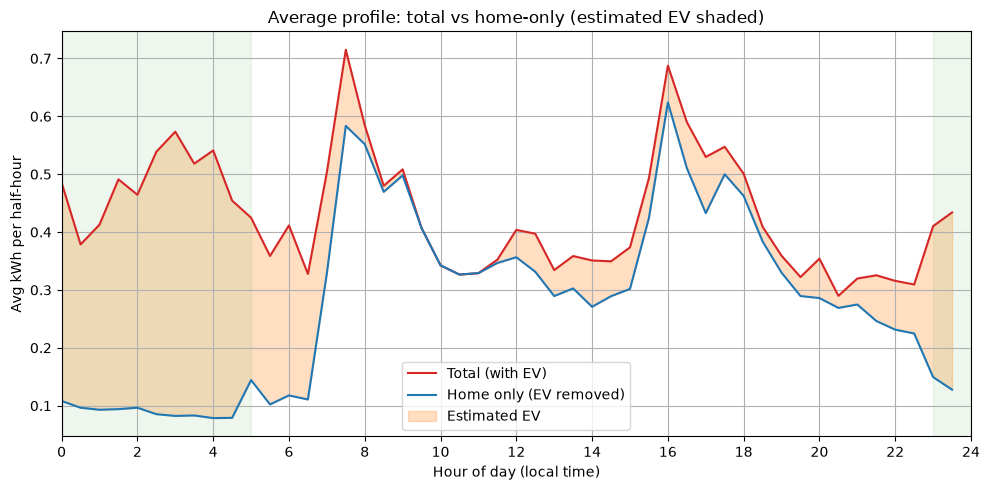

In [39]:
p = ev.assign(hour_dec=ev["start"].dt.hour + ev["start"].dt.minute / 60)
avg_total = p.groupby("hour_dec")["kwh"].mean()
avg_home = p.groupby("hour_dec")["home_kwh"].mean()

fig, ax = plt.subplots()
ax.plot(avg_total.index, avg_total.values, label="Total (with EV)", color="tab:red")
ax.plot(avg_home.index, avg_home.values, label="Home only (EV removed)", color="tab:blue")
ax.fill_between(avg_total.index, avg_home.values, avg_total.values, color="tab:orange", alpha=0.25, label="Estimated EV")
ax.axvspan(0, 5, color="tab:green", alpha=0.08)
ax.axvspan(23, 24, color="tab:green", alpha=0.08)
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 2))
ax.set_xlabel("Hour of day (local time)")
ax.set_ylabel("Avg kWh per half-hour")
ax.set_title("Average profile: total vs home-only (estimated EV shaded)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "ev_removed_profile.png", dpi=120)
plt.show()

### Re-run the battery simulation on home-only load

With EV removed, the battery only has to serve genuine household load — so it should cover far more of it, and fewer days will exceed capacity.

In [40]:
home = df.copy()
home["kwh"] = ev["home_kwh"].to_numpy()

base_rate = np.where(home["is_offpeak"].to_numpy(), OFFPEAK_RATE, PEAK_RATE)
home_load = home["kwh"].to_numpy()
home_baseline = float((home_load * base_rate).sum())
home_ideal = float(home_load.sum() * OFFPEAK_RATE)

sim_home, sim_home_res = simulate_battery(home, USABLE_KWH)

compare = pd.DataFrame(
    {
        "With EV (raw)": [
            df["kwh"].sum(), sim["baseline_cost"], sim["battery_cost"], sim["saving"],
            sim["saving"] / (actual_cost - ideal_cost), sim["peak_covered_pct"], sim["days_fully_covered"],
        ],
        "Home only (EV removed)": [
            home_load.sum(), home_baseline, sim_home["battery_cost"], sim_home["saving"],
            sim_home["saving"] / (home_baseline - home_ideal), sim_home["peak_covered_pct"], sim_home["days_fully_covered"],
        ],
    },
    index=[
        "Total kWh", "Baseline cost £", "Battery cost £", "Battery saving £",
        "% of idealised captured", "% peak load covered", "Days fully covered / 366",
    ],
)
compare.round(2)

,With EV (raw),Home only (EV removed)
Total kWh,7573.79,4926.78
Baseline cost £,1804.88,1391.00
Battery cost £,699.29,378.92
Battery saving £,1105.59,1012.08
% of idealised captured,0.86,0.96
% peak load covered,0.89,1.00
Days fully covered / 366,280.00,352.00


## Summary and further analysis

Annual saving from overnight-charge / daytime-discharge, on the full meter data and on home-only load (EV estimated out, Section 8):

| Scenario | Total kWh | Baseline cost | Battery saving | % of idealised | Days fully covered |
| :--- | ---: | ---: | ---: | ---: | ---: |
| Idealised (all off-peak) | 7,574 | £1,804.88 | £1,282.28 (71%) | 100% | — |
| Realistic, with EV (raw) | 7,574 | £1,804.88 | **£1,105.59** | 86% | 280 / 366 |
| Realistic, home-only (EV removed) | 4,927 | £1,391.00 | **£1,012.08** | **96%** | **352 / 366** |

**Key findings**

- Shortfall concentrates on **86 days**, **83** of which contain >6 kW half-hours — the daytime-EV signature (Section 7).
- Estimated EV load is **2,647 kWh/yr (35% of consumption)**, ~63% charged off-peak (Section 8, three-rule heuristic including an isolated-spike cap).
- Removing EV barely changes the **saving** (£1,106 → £1,012) because EV charging was mostly off-peak and never contributed to peak-shifting. But it lifts battery coverage of genuine home load to **~100%** and fully covers **352/366** days — so **20.7 kWh is comfortably sized for the home**; the raw data understated the fit.
- The **~£1,012/yr home-only saving** is the figure fairly attributable to the battery (EV stays on Intelligent Go's dispatched off-peak slots).

**Remaining analyses, in rough priority:**

1. **Replace estimated EV with the real charging log** when available (expected in a few months); re-run Section 8 to confirm the thresholds.
2. **Payback vs battery size** — sweep 5–30 kWh on home-only load; plot saving and simple payback vs installed cost (home-only coverage is already ~100%, so a smaller battery may pay back faster).
3. **Seasonality** — quantify the residual winter shortfall.
4. **Export arbitrage** — value overnight-charged energy exported during the day on Outgoing Octopus.

**Display recommendation:** keep this notebook as the exploratory surface (code + charts + narrative together); once figures settle, promote a short summary + the PNGs in `outputs/` into the README or the main report.